# Super Store Sales - Pilot Study (Statistics With R)

### 1. Create the data (30 observations)

In [1]:
set.seed(123)
n <- 30

data <- data.frame(
  Obs          = 1:30,
  Age          = sample(16:81, n, replace = TRUE),
  Sales_Before = sample(10:95, n, replace = TRUE),
  Sales_After  = sample(10:117, n, replace = TRUE),
  Gender       = sample(c(rep(0, 14), rep(1, 16))),
  Profession   = sample(c(rep(0, 15), rep(1, 15)))
)

data$Sales_Change <- data$Sales_After - data$Sales_Before

head(data, 10)

,Obs,Age,Sales_Before,Sales_After,Gender,Profession,Sales_Change
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>
1,1,46,78,34,0,1,-44
2,2,66,81,96,1,1,15
3,3,29,85,44,1,0,-41
4,4,57,72,49,1,1,-23
5,5,65,22,39,0,1,17
6,6,58,91,21,0,0,-70
7,7,29,34,40,1,1,6
8,8,40,47,39,1,0,-8
9,9,72,30,73,1,1,43


In [2]:
# Check counts
table(data$Gender)
table(data$Profession)


 0  1 
14 16 


 0  1 
15 15 

### 2. Descriptive statistics

In [3]:
get_mode <- function(x) {
  u <- unique(x)
  u[which.max(tabulate(match(x, u)))]
}

desc <- function(x) {
  n <- length(x); m <- mean(x); s <- sd(x)
  c(Mean     = m,
    Median   = median(x),
    Mode     = get_mode(x),
    SD       = s,
    Min      = min(x),
    Max      = max(x),
    Range    = max(x) - min(x),
    Skewness = sum((x - m)^3) / n / (sum((x - m)^2) / n)^1.5,
    Kurtosis = sum((x - m)^4) / n / (sum((x - m)^2) / n)^2 - 3,   # excess kurtosis
    SE_Mean  = s / sqrt(n))
}

stats <- round(sapply(data[, c("Age", "Sales_Before", "Sales_After")], desc), 2)
stats

,Age,Sales_Before,Sales_After
Mean,45.83,55.80,70.10
Median,46.50,53.00,78.00
Mode,24.00,78.00,39.00
SD,16.74,26.17,30.87
Min,22.00,13.00,17.00
Max,75.00,95.00,117.00
Range,53.00,82.00,100.00
Skewness,0.01,0.01,-0.19
Kurtosis,-1.21,-1.34,-1.30
SE_Mean,3.06,4.78,5.64


In [4]:
# Gender and Profession are categorical, so frequency tables are used
table(factor(data$Gender, labels = c("Female", "Male")))
table(factor(data$Profession, labels = c("Executive", "Manager")))


Female   Male 
    14     16 


Executive   Manager 
       15        15 

**Interpretation (basic guide)**
- Mean vs Median: if mean > median the data is right skewed, if mean < median it is left skewed.
- Skewness near 0 means roughly symmetric; kurtosis (excess) near 0 means normal-like peak, negative means flatter.
- Standard error of mean shows how precisely the sample mean estimates the true mean (smaller is better).
- Mean of Sales_After vs Sales_Before shows the overall effect of the discount offer.

### 3. Histograms

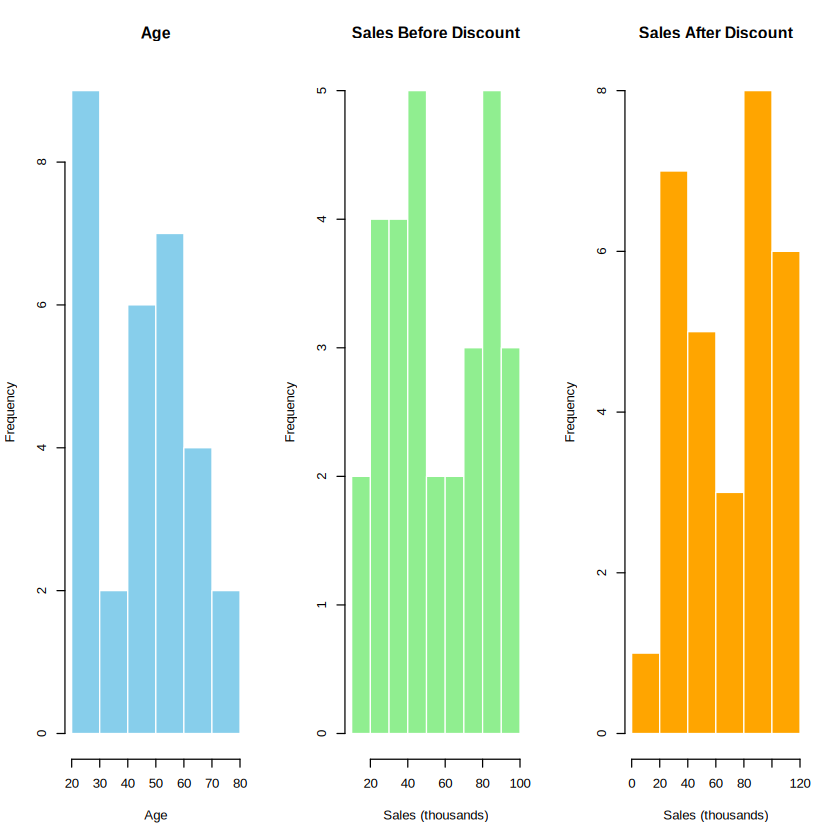

In [5]:
par(mfrow = c(1, 3))
hist(data$Age, main = "Age", xlab = "Age", col = "skyblue", border = "white")
hist(data$Sales_Before, main = "Sales Before Discount", xlab = "Sales (thousands)", col = "lightgreen", border = "white")
hist(data$Sales_After, main = "Sales After Discount", xlab = "Sales (thousands)", col = "orange", border = "white")
par(mfrow = c(1, 1))

### 4. Box-plots

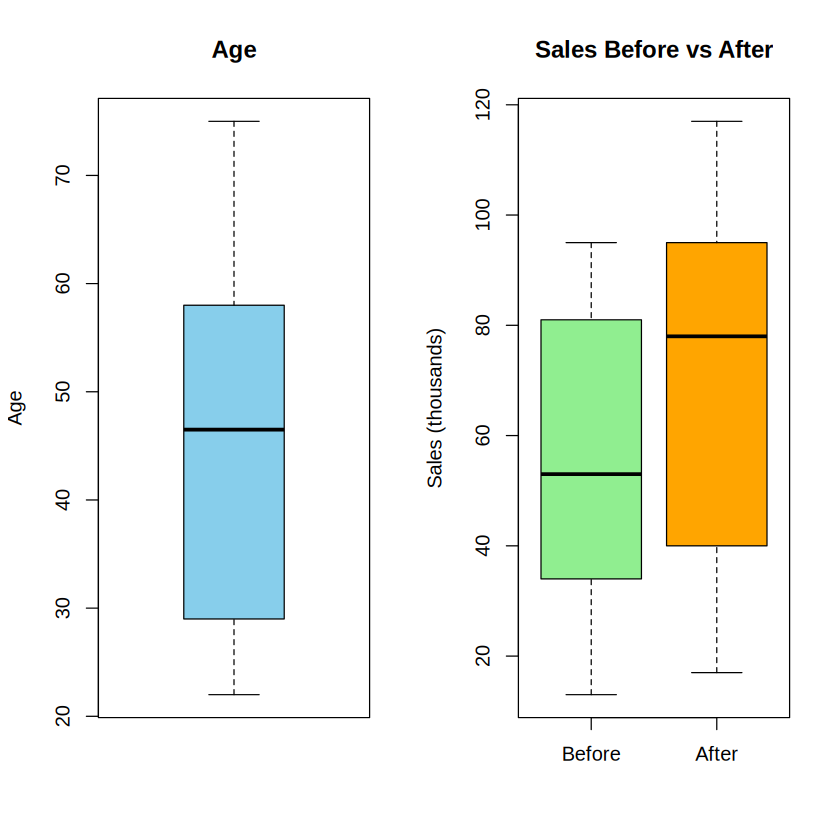

In [6]:
par(mfrow = c(1, 2))
boxplot(data$Age, main = "Age", ylab = "Age", col = "skyblue")
boxplot(data$Sales_Before, data$Sales_After,
        names = c("Before", "After"), main = "Sales Before vs After",
        ylab = "Sales (thousands)", col = c("lightgreen", "orange"))
par(mfrow = c(1, 1))

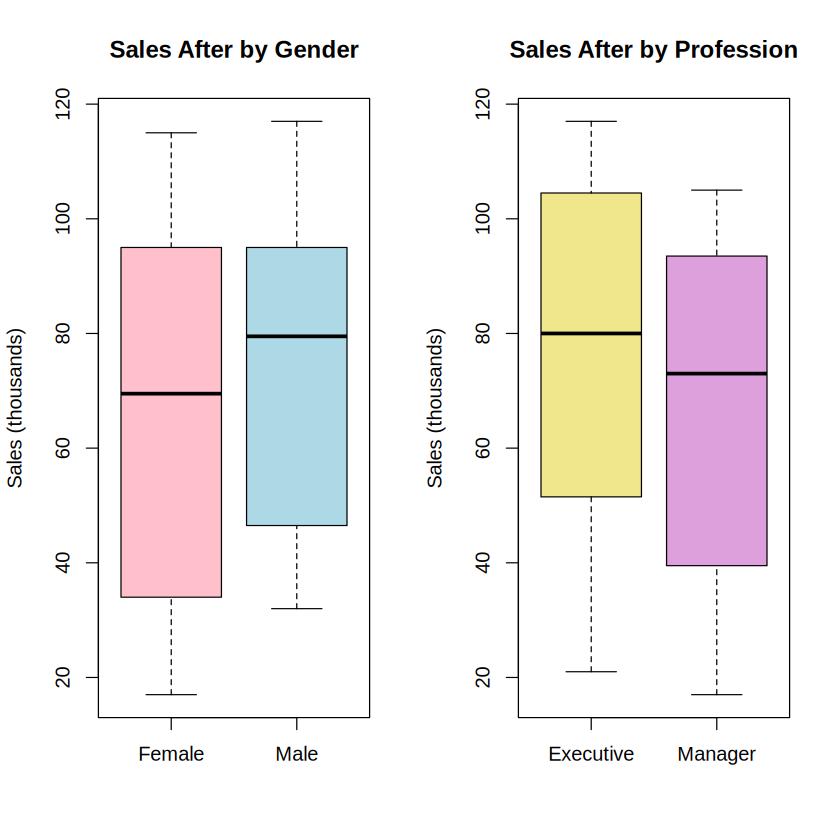

In [7]:
# Sales after discount by Gender and Profession
par(mfrow = c(1, 2))
boxplot(Sales_After ~ factor(Gender, labels = c("Female", "Male")), data = data,
        main = "Sales After by Gender", xlab = "", ylab = "Sales (thousands)", col = c("pink", "lightblue"))
boxplot(Sales_After ~ factor(Profession, labels = c("Executive", "Manager")), data = data,
        main = "Sales After by Profession", xlab = "", ylab = "Sales (thousands)", col = c("khaki", "plum"))
par(mfrow = c(1, 1))

### 5. Bar-plots

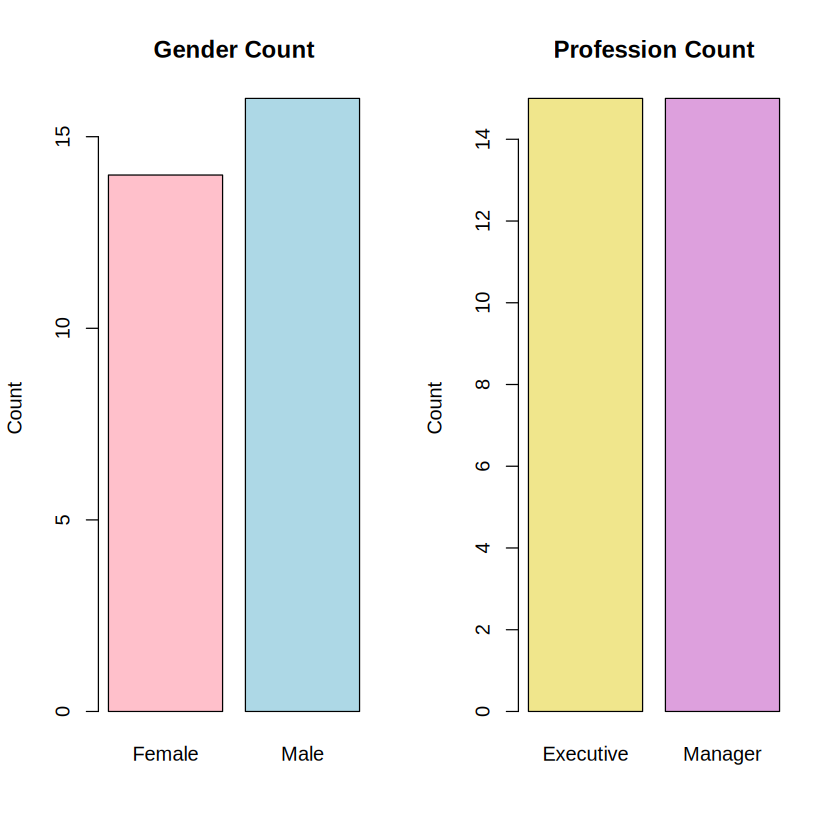

In [8]:
par(mfrow = c(1, 2))
barplot(table(factor(data$Gender, labels = c("Female", "Male"))),
        main = "Gender Count", ylab = "Count", col = c("pink", "lightblue"))
barplot(table(factor(data$Profession, labels = c("Executive", "Manager"))),
        main = "Profession Count", ylab = "Count", col = c("khaki", "plum"))
par(mfrow = c(1, 1))

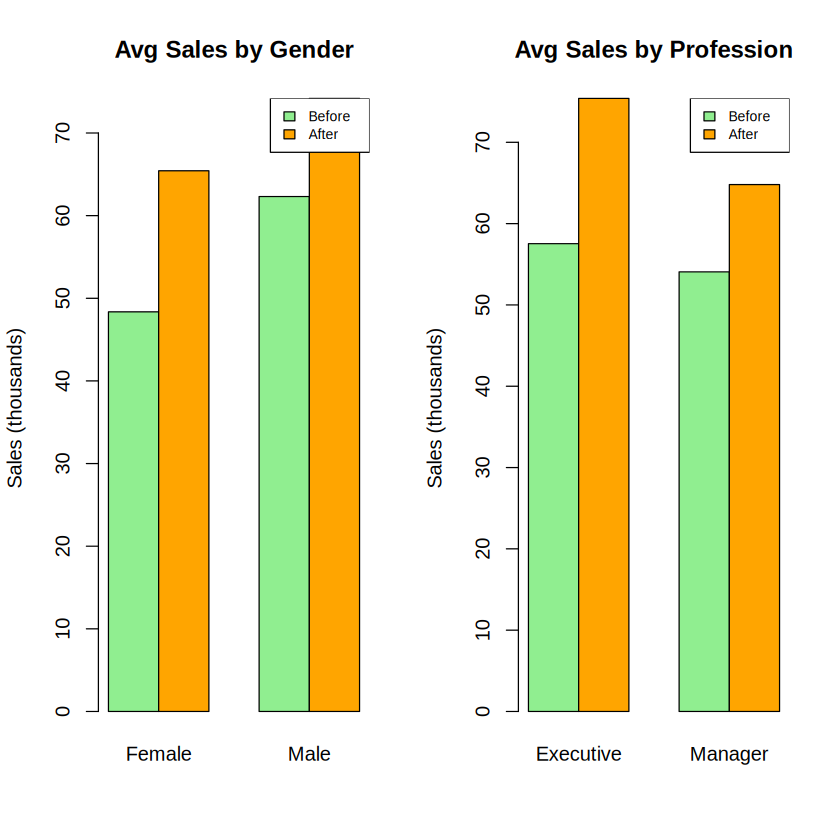

In [9]:
# Average sales before vs after by Gender and Profession
gender_avg <- rbind(tapply(data$Sales_Before, data$Gender, mean),
                    tapply(data$Sales_After,  data$Gender, mean))
colnames(gender_avg) <- c("Female", "Male")

prof_avg <- rbind(tapply(data$Sales_Before, data$Profession, mean),
                  tapply(data$Sales_After,  data$Profession, mean))
colnames(prof_avg) <- c("Executive", "Manager")

par(mfrow = c(1, 2))
barplot(gender_avg, beside = TRUE, col = c("lightgreen", "orange"),
        main = "Avg Sales by Gender", ylab = "Sales (thousands)")
legend("topright", legend = c("Before", "After"), fill = c("lightgreen", "orange"), cex = 0.7)

barplot(prof_avg, beside = TRUE, col = c("lightgreen", "orange"),
        main = "Avg Sales by Profession", ylab = "Sales (thousands)")
legend("topright", legend = c("Before", "After"), fill = c("lightgreen", "orange"), cex = 0.7)
par(mfrow = c(1, 1))

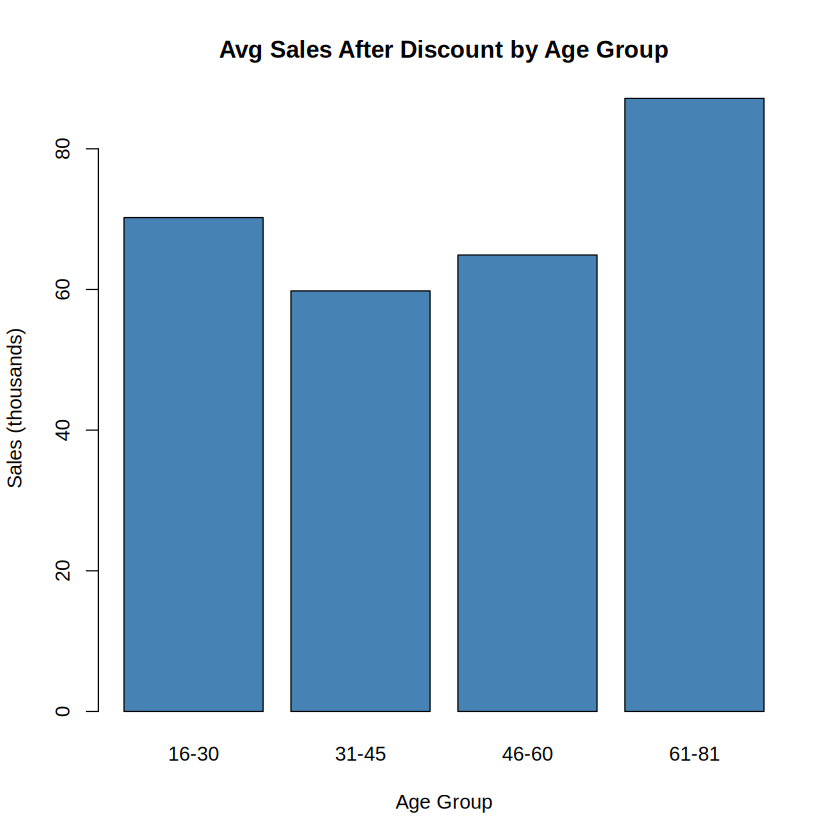

In [10]:
# Average sales after discount by age group
data$Age_Group <- cut(data$Age, breaks = c(15, 30, 45, 60, 81),
                      labels = c("16-30", "31-45", "46-60", "61-81"))

barplot(tapply(data$Sales_After, data$Age_Group, mean),
        main = "Avg Sales After Discount by Age Group",
        xlab = "Age Group", ylab = "Sales (thousands)", col = "steelblue")

### 6. Insights for the Manager

In [11]:
cat("Average sales before:", round(mean(data$Sales_Before), 2), "\n")
cat("Average sales after :", round(mean(data$Sales_After), 2), "\n")
cat("Average change      :", round(mean(data$Sales_Change), 2),
    "(", round(mean(data$Sales_Change) / mean(data$Sales_Before) * 100, 1), "% )\n")
cat("Customers whose sales increased:", sum(data$Sales_Change > 0), "out of", n, "\n\n")

cat("Avg change by Gender:\n")
print(round(tapply(data$Sales_Change, factor(data$Gender, labels = c("Female", "Male")), mean), 2))

cat("\nAvg change by Profession:\n")
print(round(tapply(data$Sales_Change, factor(data$Profession, labels = c("Executive", "Manager")), mean), 2))

cat("\nAvg change by Age Group:\n")
print(round(tapply(data$Sales_Change, data$Age_Group, mean), 2))

cat("\nCorrelation of Age with Sales After:", round(cor(data$Age, data$Sales_After), 2), "\n")

Average sales before: 55.8 
Average sales after : 70.1 
Average change      : 14.3 ( 25.6 % )
Customers whose sales increased: 18 out of 30 

Avg change by Gender:
Female   Male 
 17.07  11.88 

Avg change by Profession:
Executive   Manager 
    17.87     10.73 

Avg change by Age Group:
16-30 31-45 46-60 61-81 
 9.22  7.80 -1.40 53.50 

Correlation of Age with Sales After: 0.12 


**Key points for the Manager**
- Compare the average sales before and after to see whether the discount offer worked overall.
- The group (gender / profession / age group) with the highest average change responds best to the offer.
- A correlation close to 0 means age has little effect on buying; a high value means age matters.
- This is only a pilot study on 30 random data points, so results should be confirmed with the full survey of 2000 customers.